In [68]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')
conn = sqlite3.connect('sales.db')
df.to_sql('sales', conn, if_exists='replace', index=False)



9994

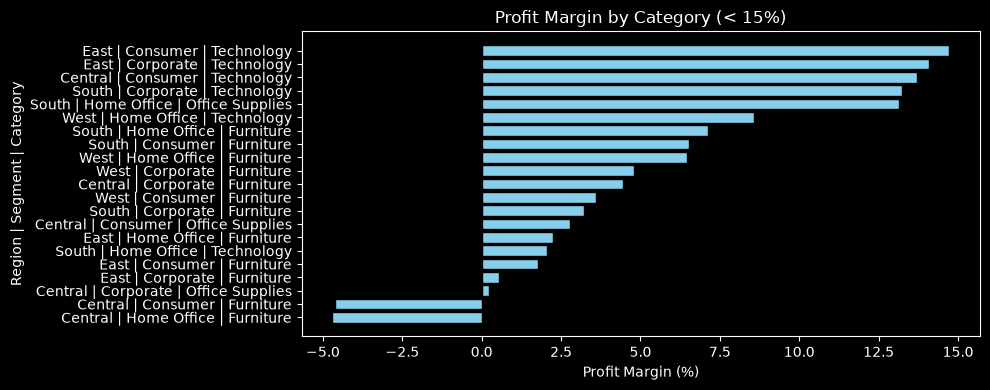

In [57]:
#Sales, profit and Profit margin calculation
sql_1 = """
SELECT "Region", "Segment", "Category", 
       ROUND(SUM("Sales"), 2) AS common_sales, 
       ROUND(SUM("Profit"), 2) AS common_profit, 
       ROUND((SUM("Profit") * 100.0 / SUM("Sales")), 2) AS average_pr 
FROM sales
GROUP BY "Region", "Segment", "Category" 
HAVING SUM("Sales") > 10000 
   AND ROUND((SUM("Profit") * 100.0 / SUM("Sales")), 2) < 15 
ORDER BY average_pr ASC;
"""

query_1 = pd.read_sql(sql_1, conn)
query_1

plt.figure(figsize=(10, 4))
#adjusted_margin = query_1["average_pr"].clip(lower=0)
query_1['group'] = query_1['Region'] + ' | ' + query_1['Segment'] + ' | ' + query_1['Category']
plt.barh(  query_1['group'], query_1['average_pr'], color='skyblue', edgecolor='black')
plt.title('Profit Margin by Category (< 15%)')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Region | Segment | Category')
plt.tight_layout()
#plt.gca().invert_yaxis()
plt.show()

In [5]:
#Data profiling
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

    total_sales   Region Sub-Category  rank_num  dense_rank_num
0    101781.328     West       Chairs         1               1
1    100614.982     East       Phones         1               1
2     98684.352     West       Phones         2               2
3     96260.683     East       Chairs         2               2
4     85230.646  Central       Chairs         1               1
..          ...      ...          ...       ...             ...
63     2353.180    South       Labels        16              16
64      923.216     West    Fasteners        17              17
65      819.718     East    Fasteners        17              17
66      778.030  Central    Fasteners        17              17
67      503.316    South    Fasteners        17              17

[68 rows x 5 columns]


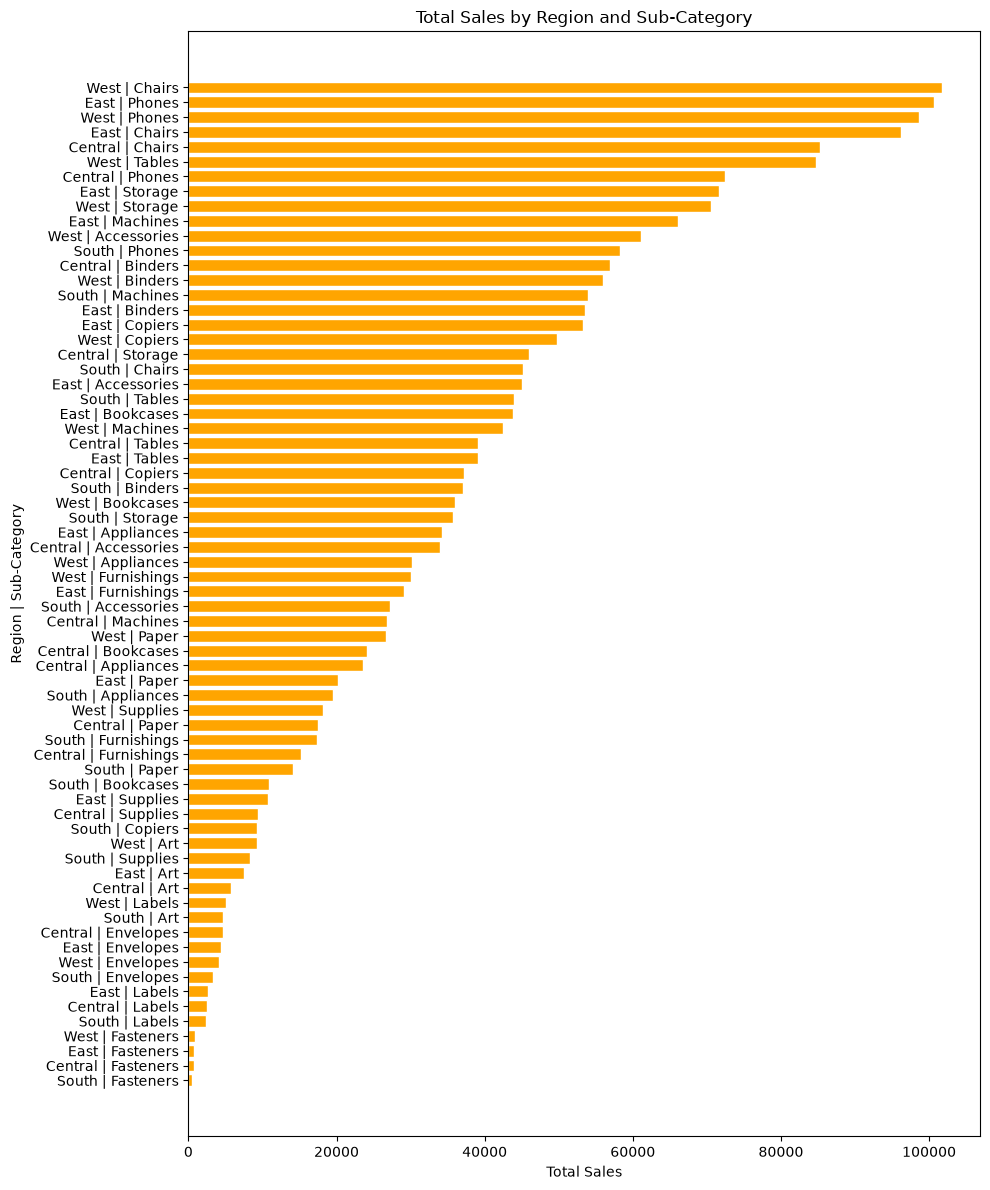

In [17]:
sql_2 = """SELECT sum("Sales") AS total_sales, "Region", "Sub-Category", Rank() OVER (PARTITION BY "Region" ORDER BY sum("Sales") desc) AS rank_num,
Dense_Rank() OVER (PARTITION BY "Region" ORDER BY sum("Sales") desc) as dense_rank_num FROM sales GROUP BY "Region", "Sub-Category" ORDER BY total_sales desc;"""
print(pd.read_sql(sql_2,conn))

query_2 = pd.read_sql(sql_2, conn)
query_2['label'] = query_2['Region'] + ' | ' + query_2['Sub-Category']
plt.figure(figsize=(10, 12))

plt.barh(query_2['label'], query_2['total_sales'], color='orange', edgecolor='white')

plt.title('Total Sales by Region and Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Region | Sub-Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [8]:
# null count checking
sql_3 = """SELECT 
    COUNT(*) - COUNT("Order ID") AS null_order_id,
    COUNT(*) - COUNT("Customer ID") AS null_customer_id,
    COUNT(*) - COUNT("Order Date") AS null_order_date,
    COUNT(*) - COUNT("Sales") AS null_sales,
    COUNT(*) - COUNT("Profit") AS null_profit
FROM sales;"""

print(pd.read_sql(sql_3, conn))

   null_order_id  null_customer_id  null_order_date  null_sales  null_profit
0              0                 0                0           0            0


        Ship Mode  avg_days_to_ship
0        Same Day              0.04
1     First Class              2.18
2    Second Class              3.24
3  Standard Class              5.01


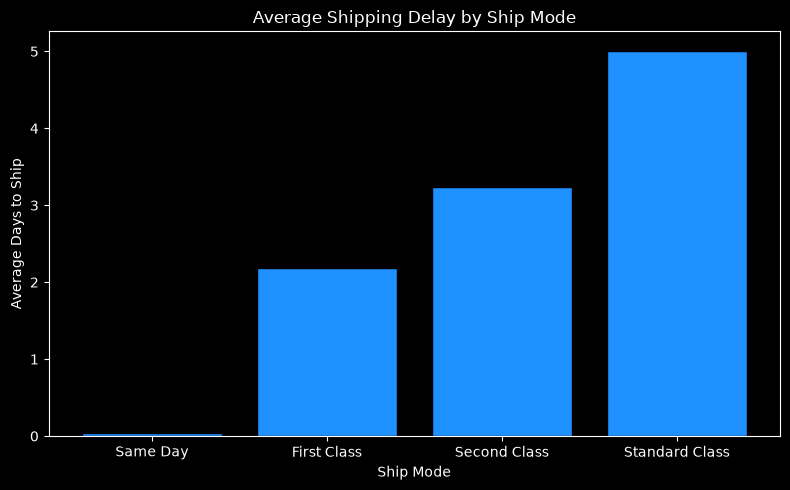

In [43]:
#Average Shipping Delay by Ship Mode
sql_4 = """select "Ship Mode",
    ROUND(AVG(JULIANDAY("Ship Date") - JULIANDAY("Order Date")), 2) AS avg_days_to_ship
FROM sales
GROUP BY "Ship Mode"
ORDER BY avg_days_to_ship ASC;"""
query_4 = pd.read_sql(sql_4, conn)
print(query_4)

plt.figure(figsize=(8, 5))
plt.bar(query_4['Ship Mode'], query_4['avg_days_to_ship'], color='dodgerblue', edgecolor='black')

plt.title('Average Shipping Delay by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Average Days to Ship')

plt.tight_layout()
plt.show()

     Region Sub-Category  total_sales  rank_num
0   Central       Chairs    85230.646         1
1   Central       Phones    72403.282         2
2   Central      Binders    56923.282         3
3   Central      Storage    45930.112         4
4   Central       Tables    39154.971         5
..      ...          ...          ...       ...
63     West     Supplies    18127.122        13
64     West          Art     9212.066        14
65     West       Labels     5078.726        15
66     West    Envelopes     4118.100        16
67     West    Fasteners      923.216        17

[68 rows x 4 columns]


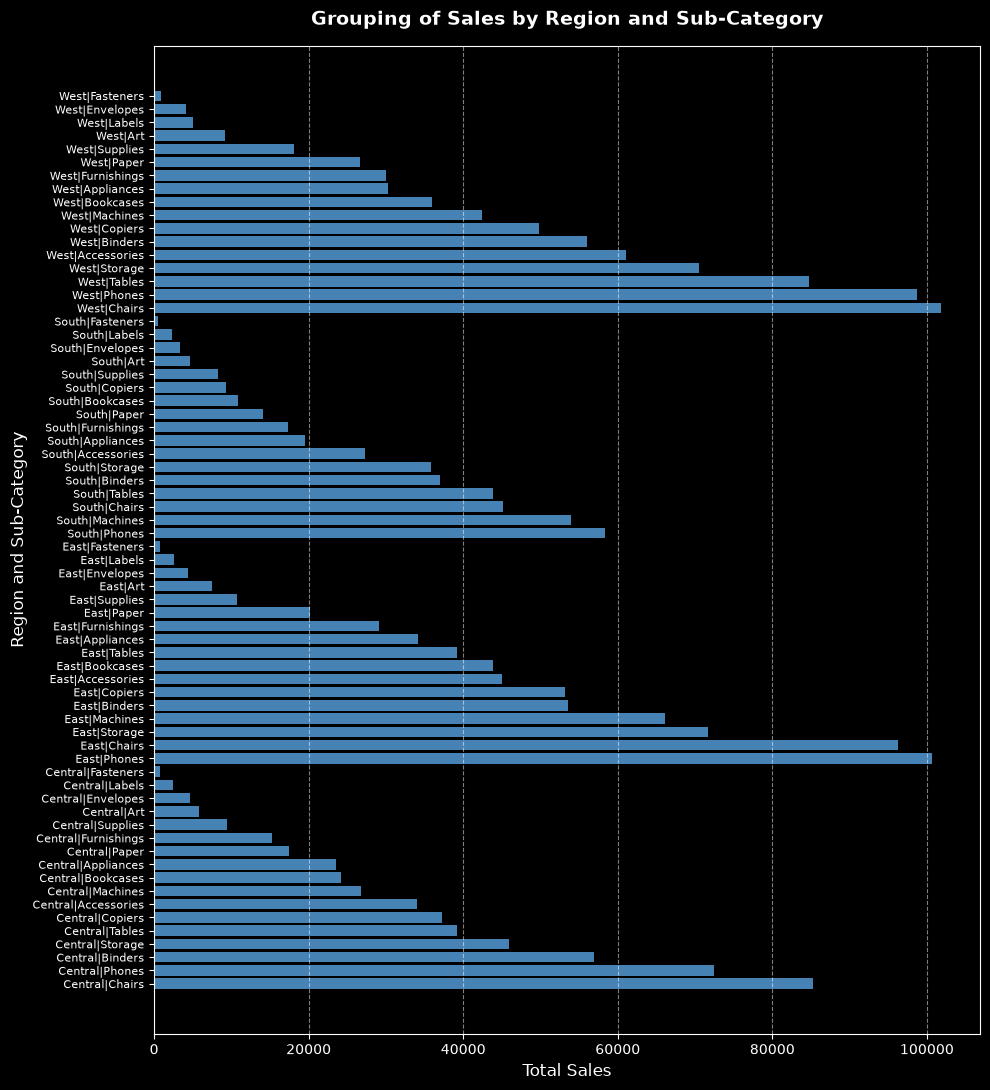

In [41]:
# Grouping of Sales by Region, Sub-Category and ranking of them
sql_5 = """select "Region", "Sub-Category", sum("Sales") as total_sales,
        DENSE_RANK() OVER (PARTITION BY "Region" ORDER BY sum("Sales") desc) AS rank_num
    from sales group by "Region", "Sub-Category";"""
query_5 = pd.read_sql(sql_5, conn)
print(query_5)

plt.figure(figsize = (10, 11))
plt.style.use('dark_background')

plt.barh(query_5["Region"] + "|" + query_5["Sub-Category"], query_5["total_sales"], color = "steelblue", edgecolor = "none")

title = plt.title('Grouping of Sales by Region and Sub-Category', fontsize=14, pad = 15, fontweight = 'bold', color = 'white', loc = 'center' )
#title.set_path_effects ([pe.Stroke(linewidth=1, foreground='white'),   pe.Normal()])

plt.ylabel('Region and Sub-Category', fontsize=12)
plt.yticks(fontsize=8)
plt.xlabel('Total Sales', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

                                        Product Name  total_sales  \
0              Canon imageCLASS 2200 Advanced Copier     61599.82   
1  Fellowes PB500 Electric Punch Plastic Comb Bin...     27453.38   
2  Cisco TelePresence System EX90 Videoconferenci...     22638.48   
3       HON 5400 Series Task Chairs for Big and Tall     21870.58   
4         GBC DocuBind TL300 Electric Binding System     19823.48   

   total_profit  
0      25199.93  
1       7753.04  
2      -1811.08  
3          0.00  
4       2233.51  


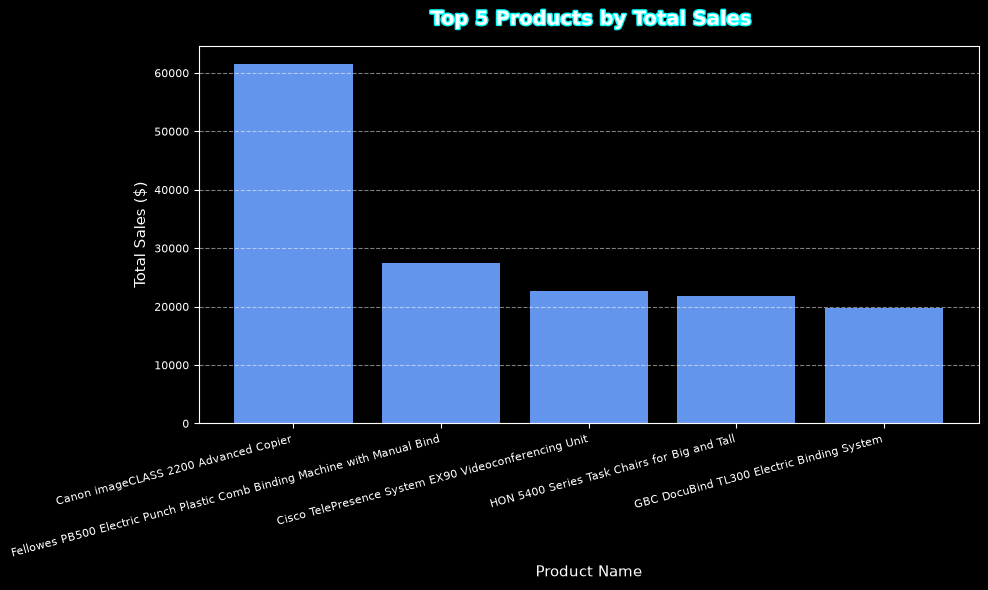

In [44]:
# Top 5 products that have the most sales
sql_6 = """select "Product Name",  ROUND(SUM("Sales"), 2) AS total_sales,
    ROUND(SUM("Profit"), 2) AS total_profit from sales group by "Product Name" order by total_sales desc limit 5;"""
query_6 = pd.read_sql(sql_6, conn)
print(query_6)

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

plt.bar(
    query_6["Product Name"], 
    query_6["total_sales"], 
    color="cornflowerblue", 
    edgecolor="none"
)

t = plt.title('Top 5 Products by Total Sales', fontsize=14, fontweight='bold', color='white', pad=15)
t.set_path_effects([
    pe.Stroke(linewidth=2, foreground='cyan'), 
    pe.Normal()
])

plt.xlabel('Product Name', fontsize=11)
plt.ylabel('Total Sales ($)', fontsize=11)

plt.xticks(rotation=15, fontsize=8, ha='right')
plt.yticks(fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

   status                                       Product Name  total_sales
0     top              Canon imageCLASS 2200 Advanced Copier     61599.82
1     top  Fellowes PB500 Electric Punch Plastic Comb Bin...     27453.38
2     top  Cisco TelePresence System EX90 Videoconferenci...     22638.48
3     top       HON 5400 Series Task Chairs for Big and Tall     21870.58
4     top         GBC DocuBind TL300 Electric Binding System     19823.48
5  bottom  Eureka Disposable Bags for Sanitaire Vibra Gro...         1.62
6  bottom                                            Avery 5         5.76
7  bottom                                           Xerox 20         6.48
8  bottom                                Grip Seal Envelopes         7.07
9  bottom  Avery Hi-Liter Pen Style Six-Color Fluorescent...         7.70


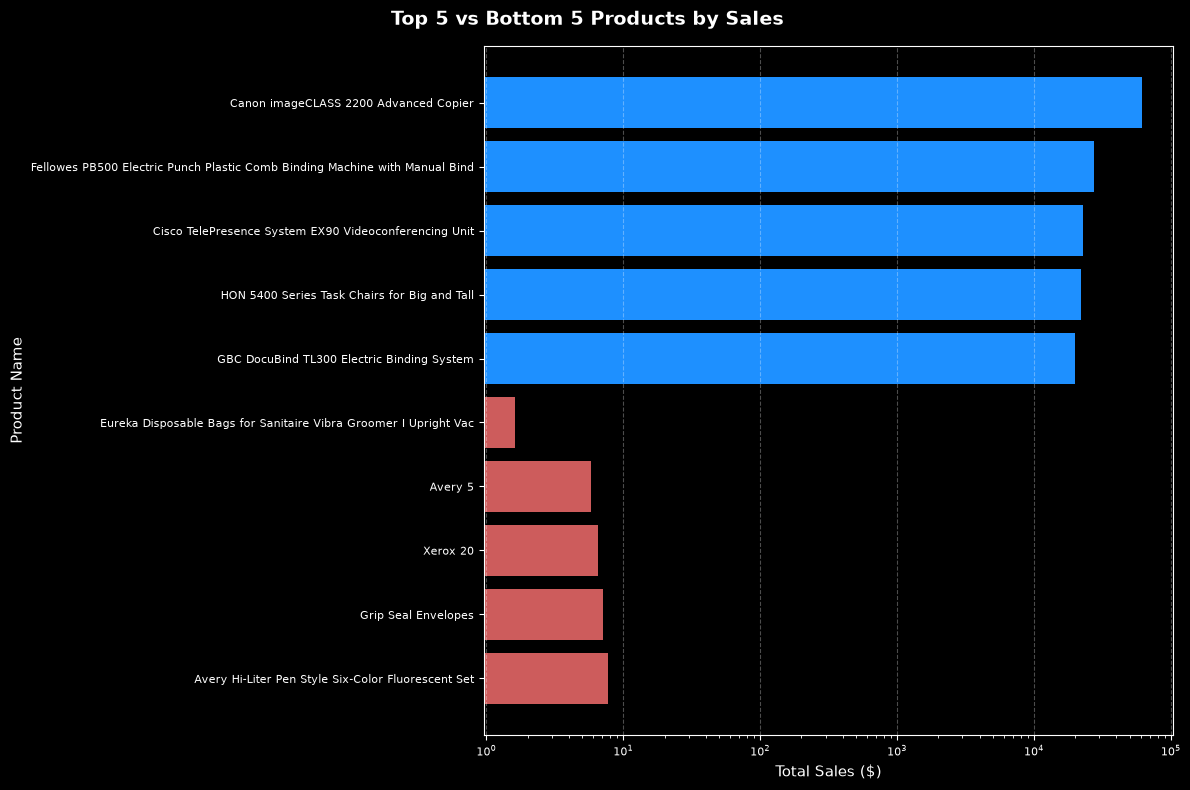

In [58]:
# Top 5 and Bottom 5 Products
sql_7 = """
SELECT * FROM(SELECT 'top' AS status, 
       "Product Name", 
       ROUND(SUM("Sales"), 2) AS total_sales
FROM sales
GROUP BY "Product Name"
ORDER BY total_sales DESC
LIMIT 5)
UNION ALL
SELECT * FROM(SELECT 'bottom' AS status, 
       "Product Name", 
       ROUND(SUM("Sales"), 2) AS total_sales
FROM sales
GROUP BY "Product Name"
ORDER BY total_sales ASC
LIMIT 5);
"""
query_7 = pd.read_sql(sql_7, conn)
print(query_7)

plt.style.use('dark_background')
plt.figure(figsize=(12, 8))

colors = ['dodgerblue' if status == 'top' else 'indianred' for status in query_7['status']]
plt.barh(
    query_7["Product Name"], 
    query_7["total_sales"], 
    color=colors, 
    edgecolor="none"
)
plt.xscale('log')

plt.title('Top 5 vs Bottom 5 Products by Sales', fontsize=14, fontweight='bold', color='white', pad=15, x = 0.15)

plt.xlabel('Total Sales ($)', fontsize=11)
plt.ylabel('Product Name', fontsize=11)

plt.yticks(fontsize=8)
plt.xticks(fontsize=8)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

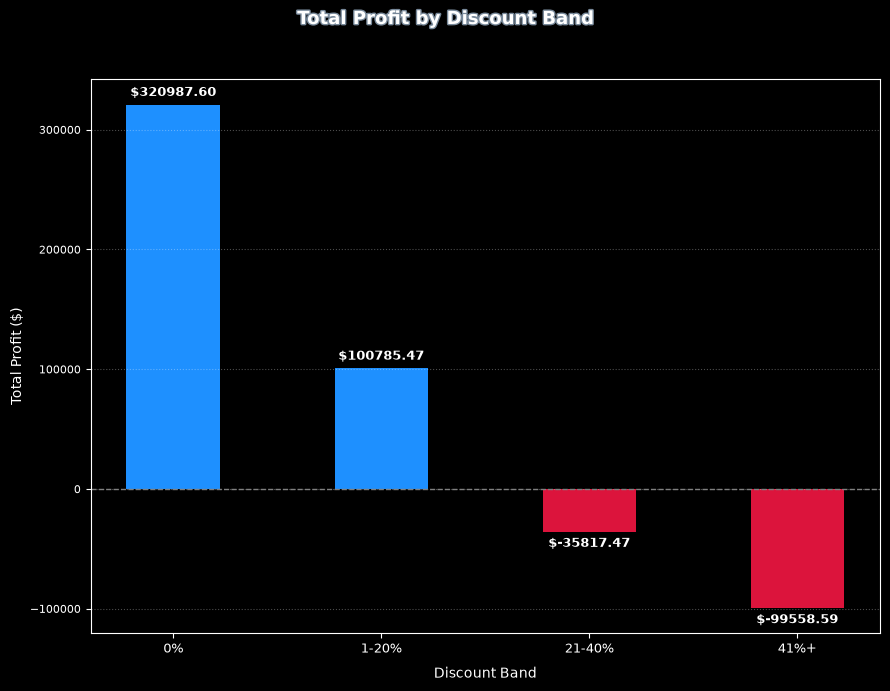

In [63]:
# discount band analysis
sql_8 = """
SELECT 
    CASE 
        WHEN discount = 0 THEN '0%'
        WHEN discount > 0 AND discount <= 0.20 THEN '1-20%'
        WHEN discount > 0.20 AND discount <= 0.40 THEN '21-40%'
        ELSE '41%+'
    END AS discount_band, 
    ROUND(SUM(profit), 2) AS total_profit 
FROM sales 
GROUP BY discount_band;
"""

query_8 = pd.read_sql(sql_8, conn)

plt.style.use('dark_background')
plt.figure(figsize=(9, 7))

custom_colors = ['dodgerblue', 'cadetblue', 'deepskyblue', 'crimson']

colors = [
    'dodgerblue' if val > 50000 
    else 'cadetblue' if val >= 0 
    else 'crimson' 
    for val in query_8['total_profit']
]

bars = plt.bar(
    query_8["discount_band"], 
    query_8["total_profit"], 
    color=colors, 
    edgecolor="none",
    width=0.45
)

plt.bar_label(bars, fmt='$%.2f', padding=4, fontsize=9, color='white', fontweight='bold')

t = plt.suptitle('Total Profit by Discount Band', fontsize=13, fontweight='bold', color='white', y=0.98)
t.set_path_effects([
    pe.Stroke(linewidth=2, foreground='lightslategrey'), 
    pe.Normal()
])

plt.xlabel('Discount Band', fontsize=10, labelpad=8)
plt.ylabel('Total Profit ($)', fontsize=10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=8)

plt.axhline(0, color='gray', linewidth=1, linestyle='--')

plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

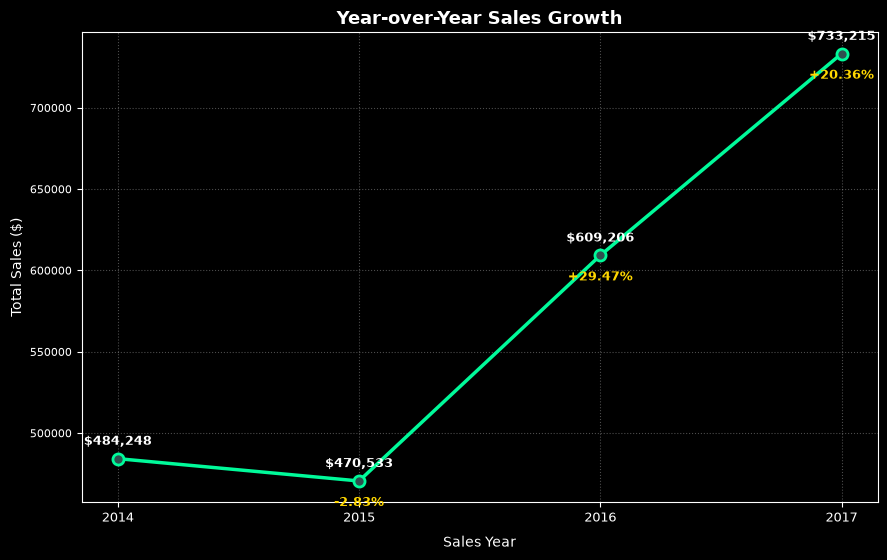

In [79]:
# Year-over-year sales Growth Analysis
sql_9 = """
WITH YearlySales AS (
    SELECT 
        STRFTIME('%Y', "Order Date") AS sales_year, 
        SUM("Sales") AS current_year_sales 
    FROM sales 
    GROUP BY sales_year
)
SELECT 
    sales_year, 
    ROUND(current_year_sales, 2) AS total_sales, 
    COALESCE(ROUND(LAG(current_year_sales) OVER (ORDER BY sales_year), 2), 0) AS prev_year_sales, 
    COALESCE(ROUND(current_year_sales - LAG(current_year_sales) OVER (ORDER BY sales_year), 2), 0) AS absolute_change, 
    COALESCE(ROUND(((current_year_sales - LAG(current_year_sales) OVER (ORDER BY sales_year)) / LAG(current_year_sales) OVER (ORDER BY sales_year)) * 100, 2), 0) AS yoy_percentage_change
FROM YearlySales 
ORDER BY sales_year;
"""
query_9 = pd.read_sql(sql_9, conn)

plt.style.use('dark_background')
plt.figure(figsize=(9, 6))

colors = ['steelblue', 'teal', 'cadetblue', 'dodgerblue']

line = plt.plot(
    query_9["sales_year"], 
    query_9["total_sales"], 
    color="mediumspringgreen", 
    marker="o", 
    linewidth=2.5, 
    markersize=8, 
    markerfacecolor="darkslategrey", 
    markeredgecolor="mediumspringgreen", 
    markeredgewidth=2
)

for i, row in query_9.iterrows():
    val_text = f"${row['total_sales']:,.0f}"
    plt.annotate(
        val_text,
        (row["sales_year"], row["total_sales"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='white'
    )

for i, row in query_9.iterrows():
    if row['yoy_percentage_change'] != 0:
        pct_text = f"+{row['yoy_percentage_change']}%" if row['yoy_percentage_change'] > 0 else f"{row['yoy_percentage_change']}%"
        plt.annotate(
            pct_text,
            (row["sales_year"], row["total_sales"]),
            textcoords="offset points",
            xytext=(0, -18),
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='gold'
        )

plt.title('Year-over-Year Sales Growth', fontsize=13, fontweight='bold', color='white')

plt.xlabel('Sales Year', fontsize=10, labelpad=8)
plt.ylabel('Total Sales ($)', fontsize=10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=8)

plt.grid(axis='both', linestyle=':', alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

  customer_id         customer_name  total_orders  total_profit  \
0    TC-20980          Tamara Chand             5       8981.32   
1    RB-19360          Raymond Buch             6       6976.10   
2    SC-20095          Sanjit Chand             9       5757.41   
3    HL-15040          Hunter Lopez             6       5622.43   
4    AB-10105         Adrian Barton            10       5444.81   
5    TA-21385          Tom Ashbrook             4       4703.79   
6    CM-12385  Christopher Martinez             4       3899.89   
7    KD-16495         Keith Dawkins            12       3038.63   
8    AR-10540           Andy Reiter             6       2884.62   
9    DR-12940         Daniel Raglin             8       2869.08   

   avg_order_value  
0          3810.44  
1          2519.56  
2          1571.37  
3          2145.55  
4          1447.36  
5          3648.91  
6          2238.51  
7           681.77  
8          1101.41  
9          1043.86  


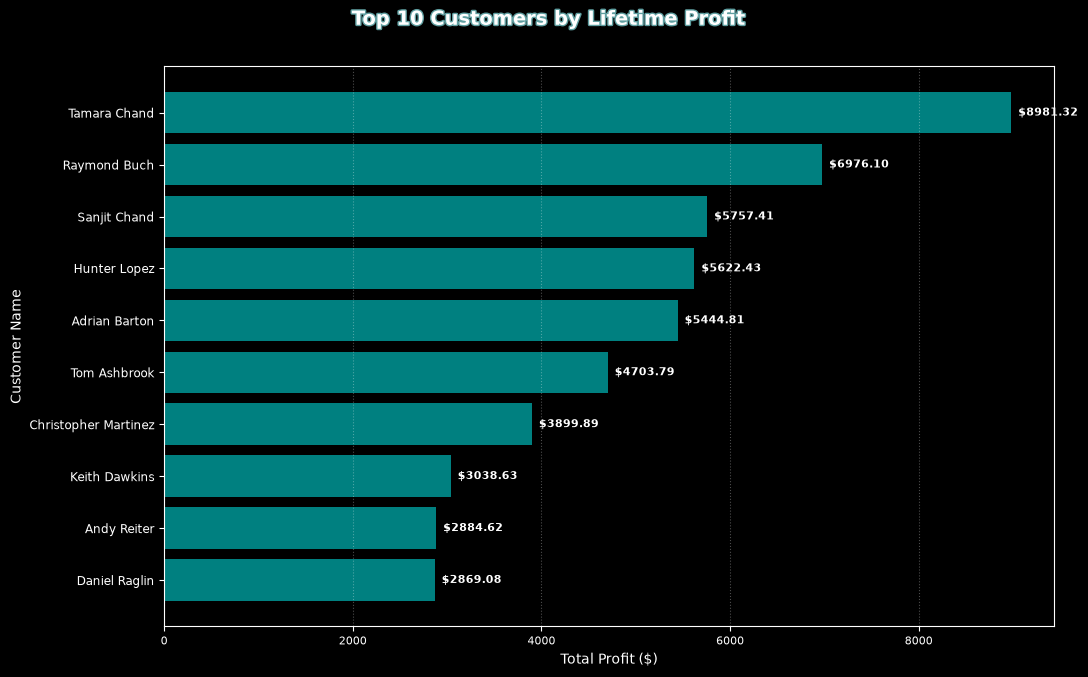

In [67]:
#top 10 customer by lifetime profit
sql_10 = """select "Customer ID" AS customer_id, 
    "Customer Name" AS customer_name, 
    COUNT(DISTINCT "Order ID") AS total_orders, 
    ROUND(SUM("Profit"), 2) AS total_profit, 
    ROUND(SUM("Sales") / COUNT(DISTINCT "Order ID"), 2) AS avg_order_value 
FROM sales 
GROUP BY "Customer ID", "Customer Name" 
ORDER BY total_profit DESC 
LIMIT 10;"""
query_10 = pd.read_sql(sql_10, conn)
print (query_10)

plt.style.use('dark_background')
plt.figure(figsize=(11, 7))

bars = plt.barh(
    query_10["customer_name"], 
    query_10["total_profit"], 
    color="teal", 
    edgecolor="none"
)

plt.bar_label(bars, fmt='$%.2f', padding=5, fontsize=8, color='white', fontweight='bold')

t = plt.suptitle('Top 10 Customers by Lifetime Profit', fontsize=14, fontweight='bold', color='white', y=0.96)
t.set_path_effects([
    pe.Stroke(linewidth=2, foreground='cadetblue'), 
    pe.Normal()
])

plt.xlabel('Total Profit ($)', fontsize=10)
plt.ylabel('Customer Name', fontsize=10)

plt.yticks(fontsize=8.5)
plt.xticks(fontsize=8)

plt.grid(axis='x', linestyle=':', alpha=0.3)
plt.gca().invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

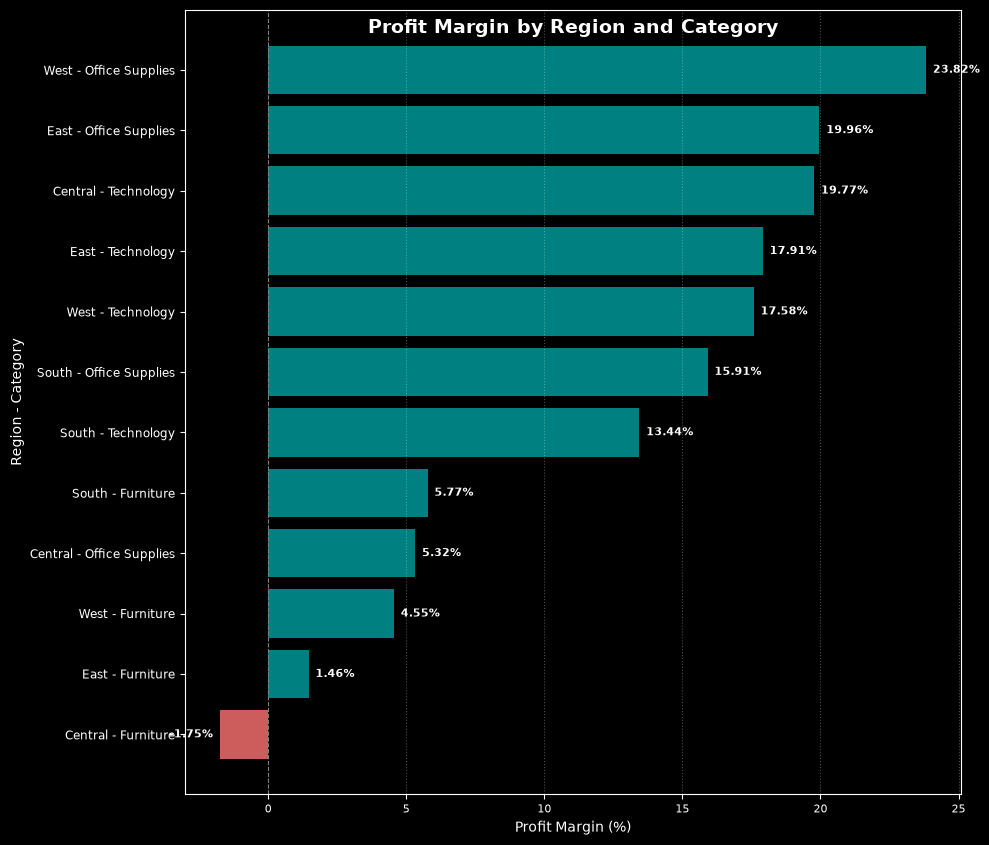

In [72]:
# Region and category list according to the profit_margin
sql_11 = """SELECT 
    "Region",
    "Category",
    ROUND(SUM("Sales"), 2) AS total_sales,
    ROUND(SUM("Profit"), 2) AS total_profit,
    ROUND((SUM("Profit") / SUM("Sales") * 100), 2) AS profit_margin
FROM sales
GROUP BY "Region", "Category"
ORDER BY profit_margin DESC;
"""
query_11 = pd.read_sql(sql_11, conn)

query_11["region_category"] = query_11["Region"] + " - " + query_11["Category"]

plt.style.use('dark_background')
plt.figure(figsize=(10, 9))

colors = ['teal' if val >= 0 else 'indianred' for val in query_11['profit_margin']]

bars = plt.barh(
    query_11["region_category"], 
    query_11["profit_margin"], 
    color=colors, 
    edgecolor="none"
)

plt.bar_label(bars, fmt='%.2f%%', padding=5, fontsize=8, color='white', fontweight='bold')

plt.title('Profit Margin by Region and Category', fontsize=14, fontweight='bold', color='white', y=0.96)

plt.xlabel('Profit Margin (%)', fontsize=10)
plt.ylabel('Region - Category', fontsize=10)

plt.yticks(fontsize=8.5)
plt.xticks(fontsize=8)

plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.grid(axis='x', linestyle=':', alpha=0.3)
plt.gca().invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

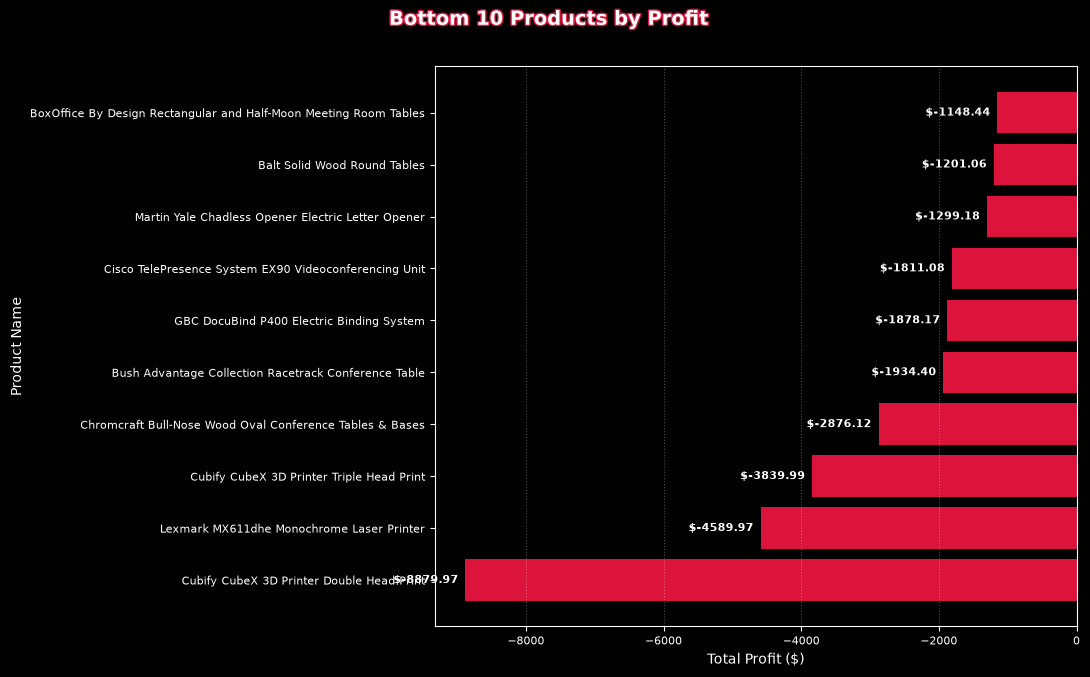

In [75]:
#bottom 10 product name having the less profit 
sql_12 = """SELECT "Product Name" AS product_name, ROUND(SUM("Profit"), 2) AS total_profit
FROM sales  
GROUP BY "Product Name" 
ORDER BY total_profit ASC 
LIMIT 10;
"""
query_12 = pd.read_sql(sql_12, conn)

plt.style.use('dark_background')
plt.figure(figsize=(11, 7))

bars = plt.barh(
    query_12["product_name"], 
    query_12["total_profit"], 
    color="crimson", 
    edgecolor="none"
)

plt.bar_label(bars, fmt='$%.2f', padding=5, fontsize=8, color='white', fontweight='bold')

t = plt.suptitle('Bottom 10 Products by Profit', fontsize=14, fontweight='bold', color='white', y=0.96)
t.set_path_effects([
    pe.Stroke(linewidth=2, foreground='crimson'), 
    pe.Normal()
])

plt.xlabel('Total Profit ($)', fontsize=10)
plt.ylabel('Product Name', fontsize=10)

plt.yticks(fontsize=8)
plt.xticks(fontsize=8)

plt.grid(axis='x', linestyle=':', alpha=0.3)
#plt.gca().invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


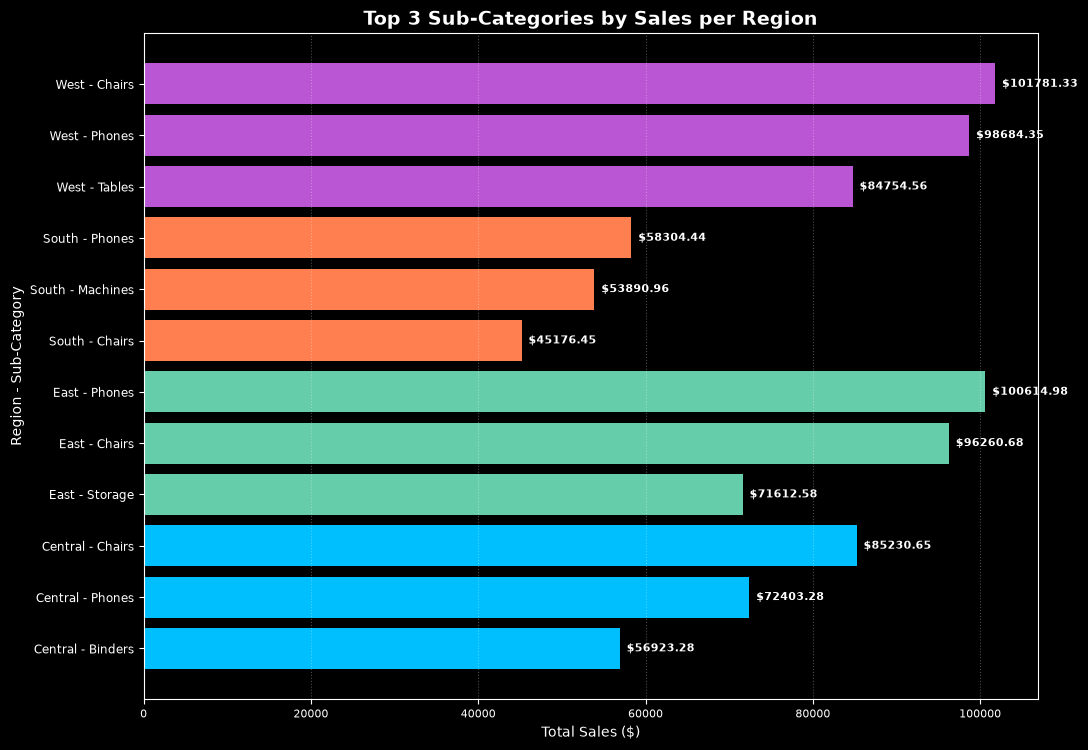

In [82]:
# Top 3 ranked categories for each region
sql_13 = """
WITH RankedCategories AS (
    SELECT 
        "Region",
        "Sub-Category",
        ROUND(SUM("Sales"), 2) AS total_sales,
        ROW_NUMBER() OVER (
            PARTITION BY "Region" 
            ORDER BY SUM("Sales") DESC
        ) AS sales_rank
    FROM sales
    GROUP BY "Region", "Sub-Category"
)
SELECT "Region", "Sub-Category", total_sales
FROM RankedCategories
WHERE sales_rank <= 3
ORDER BY "Region", total_sales ASC;
"""
query_13 = pd.read_sql(sql_13, conn)

query_13["region_subcat"] = query_13["Region"] + " - " + query_13["Sub-Category"]

plt.style.use('dark_background')
plt.figure(figsize=(11, 8))

region_colors = {
    'Central': 'deepskyblue',
    'East': 'mediumaquamarine',
    'South': 'coral',
    'West': 'mediumorchid'
}
colors = [region_colors.get(reg, 'dodgerblue') for reg in query_13['Region']]

bars = plt.barh(
    query_13["region_subcat"], 
    query_13["total_sales"], 
    color=colors, 
    edgecolor="none"
)

plt.bar_label(bars, fmt='$%.2f', padding=5, fontsize=8, color='white', fontweight='bold')

plt.title('Top 3 Sub-Categories by Sales per Region', fontsize=14, fontweight='bold', color='white')


plt.xlabel('Total Sales ($)', fontsize=10)
plt.ylabel('Region - Sub-Category', fontsize=10)

plt.yticks(fontsize=8.5)
plt.xticks(fontsize=8)

plt.grid(axis='x', linestyle=':', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

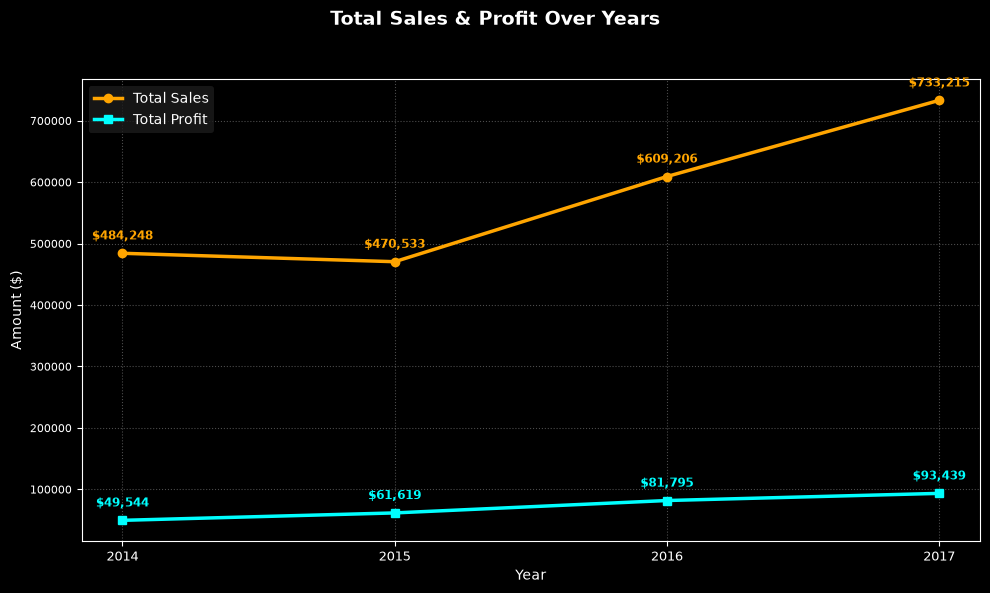

In [84]:
# Total_sales and total_profit over years 
sql_14 = """
SELECT 
    STRFTIME('%Y', "Order Date") AS year,
    ROUND(SUM("Sales"), 2) AS total_sales,
    ROUND(SUM("Profit"), 2) AS total_profit
FROM sales
GROUP BY year
ORDER BY year ASC;
"""
query_14 = pd.read_sql(sql_14, conn)

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

plt.plot(
    query_14["year"], 
    query_14["total_sales"], 
    color="orange", 
    marker="o", 
    linewidth=2.5, 
    label="Total Sales"
)

plt.plot(
    query_14["year"], 
    query_14["total_profit"], 
    color="cyan", 
    marker="s", 
    linewidth=2.5, 
    label="Total Profit"
)

for i, row in query_14.iterrows():
    plt.annotate(
        f"${row['total_sales']:,.0f}",
        (row["year"], row["total_sales"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=8.5,
        fontweight='bold',
        color='orange'
    )
    plt.annotate(
        f"${row['total_profit']:,.0f}",
        (row["year"], row["total_profit"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=8.5,
        fontweight='bold',
        color='cyan'
    )

plt.suptitle('Total Sales & Profit Over Years', fontsize=14, fontweight='bold', color='white', y=0.98)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Amount ($)', fontsize=10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=8)

plt.legend(loc="upper left", frameon=True, facecolor="#1c1c1c", edgecolor="none")
plt.grid(axis='both', linestyle=':', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

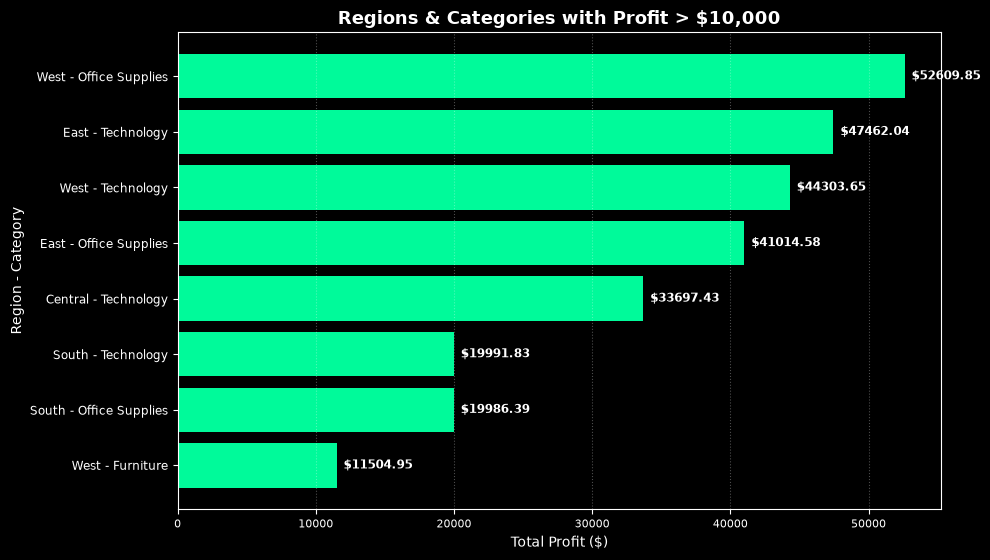

In [86]:
# Regions and categories with profit greater than 10,000
sql_15 = """
SELECT 
    "Region", 
    "Category", 
    ROUND(SUM("Profit"), 2) AS total_profit
FROM sales 
GROUP BY "Region", "Category" 
HAVING SUM("Profit") > 10000 
ORDER BY total_profit ASC;
"""
query_15 = pd.read_sql(sql_15, conn)

query_15["region_category"] = query_15["Region"] + " - " + query_15["Category"]

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

bars = plt.barh(
    query_15["region_category"], 
    query_15["total_profit"], 
    color="mediumspringgreen", 
    edgecolor="none"
)

plt.bar_label(bars, fmt='$%.2f', padding=5, fontsize=8.5, color='white', fontweight='bold')

plt.title('Regions & Categories with Profit > $10,000', fontsize=13, fontweight='bold', color='white')
plt.xlabel('Total Profit ($)', fontsize=10)
plt.ylabel('Region - Category', fontsize=10)

plt.yticks(fontsize=8.5)
plt.xticks(fontsize=8)

plt.grid(axis='x', linestyle=':', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

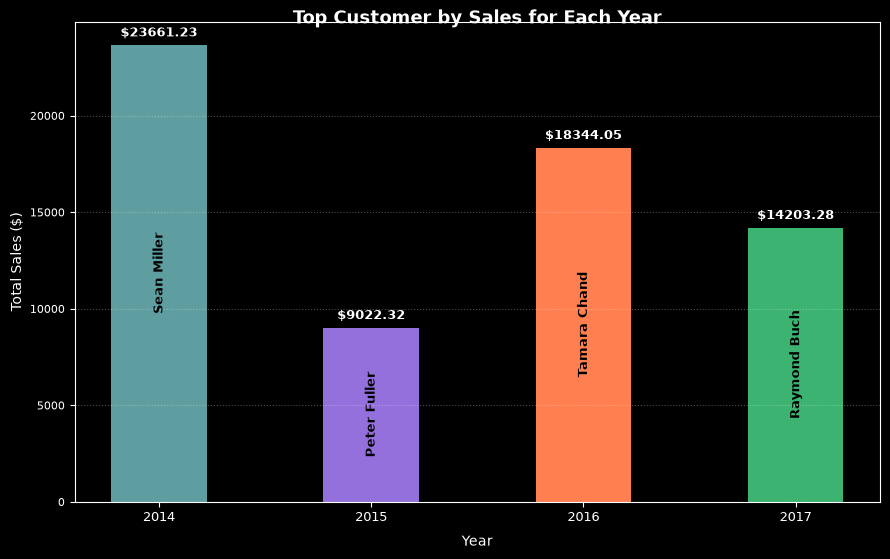

In [87]:
# Top 1 customer for every year
sql_16 = """
WITH CustomerSales AS (
    SELECT 
        STRFTIME('%Y', "Order Date") AS order_year,
        "Customer Name" AS customer_name,
        ROUND(SUM("Sales"), 2) AS total_sales, 
        ROW_NUMBER() OVER (
            PARTITION BY STRFTIME('%Y', "Order Date") 
            ORDER BY SUM("Sales") DESC
        ) AS ys
    FROM sales 
    GROUP BY order_year, customer_name
) 
SELECT order_year, customer_name, total_sales
FROM CustomerSales
WHERE ys = 1
ORDER BY order_year ASC;
"""
query_16 = pd.read_sql(sql_16, conn)

plt.style.use('dark_background')
plt.figure(figsize=(9, 6))

colors = ['cadetblue', 'mediumpurple', 'coral', 'mediumseagreen']

bars = plt.bar(
    query_16["order_year"], 
    query_16["total_sales"], 
    color=colors, 
    edgecolor="none",
    width=0.45
)

plt.bar_label(bars, fmt='$%.2f', padding=4, fontsize=9, color='white', fontweight='bold')

for i, row in query_16.iterrows():
    plt.text(
        x=i, 
        y=row['total_sales'] / 2, 
        s=row['customer_name'], 
        ha='center', 
        va='center', 
        fontsize=9, 
        fontweight='bold', 
        color='black',
        rotation=90
    )

plt.title('Top Customer by Sales for Each Year', fontsize=13, fontweight='bold', color='white', y=0.98)
plt.xlabel('Year', fontsize=10, labelpad=8)
plt.ylabel('Total Sales ($)', fontsize=10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=8)

plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

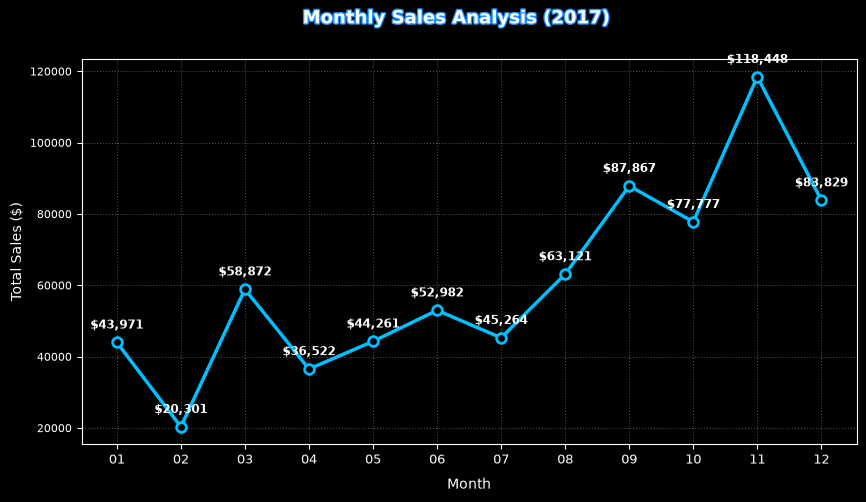

In [89]:
# monthly sales analysis for 2017
sql_17 = """
SELECT 
    STRFTIME('%m', "Order Date") AS month,
    COUNT(DISTINCT "Order ID") AS unique_orders,
    ROUND(SUM("Sales"), 2) AS total_sales
FROM sales
WHERE STRFTIME('%Y', "Order Date") = '2017'
GROUP BY month
ORDER BY month ASC;
"""
query_17 = pd.read_sql(sql_17, conn)

plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

plt.plot(
    query_17["month"], 
    query_17["total_sales"], 
    color="deepskyblue", 
    marker="o", 
    linewidth=2.5, 
    markersize=7,
    markerfacecolor="black",
    markeredgecolor="deepskyblue",
    markeredgewidth=2
)

for i, row in query_17.iterrows():
    plt.annotate(
        f"${row['total_sales']:,.0f}",
        (row["month"], row["total_sales"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=8.5,
        fontweight='bold',
        color='white'
    )

t = plt.suptitle('Monthly Sales Analysis (2017)', fontsize=13, fontweight='bold', color='white', y=0.98)
t.set_path_effects([
    pe.Stroke(linewidth=2, foreground='dodgerblue'), 
    pe.Normal()
])

plt.xlabel('Month', fontsize=10, labelpad=8)
plt.ylabel('Total Sales ($)', fontsize=10)

plt.xticks(fontsize=9)
plt.yticks(fontsize=8)

plt.grid(axis='both', linestyle=':', alpha=0.3)